## 📎 Code this notebook uses
*(full map of every notebook → [`README.md`](README.md))*

- **Figures — `pipeline/figures/`:** `make_alpha_sweep_figure`, `make_results_figures`


# 04 — Discussion figures and tables

The final notebook: the **Discussion** figures plus the model-comparison
table, then a closing check that every paper figure exists on disk. Reads
the retrieval JSON from notebook 02; run that one first.

| Output | Generator |
|---|---|
| Fig 10 — Robustness of inter-site contrast | `make_results_figures.fig_robustness` |
| Fig 11 — α-sweep (Martínez per-site density) | `make_alpha_sweep_figure.main` |
| Table 4 — Pooled-fit model comparison | inlined |

In [1]:
import sys, json, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'src'))
sys.path.insert(0, str(ROOT / 'pipeline' / 'figures'))
OUTPUT = ROOT / 'results'
FIGS = ROOT.parent / 'figures'   # shared top-level figures/ (what documents read)

d = json.loads((OUTPUT / 'kd_retrieval_results.json').read_text())

from IPython.display import Image, display
import io
def show_fig(name):
    """Display a figure inline. Prefers the PNG companion; falls back to
    rendering the PDF on the fly via pymupdf if no PNG exists."""
    stem = name.replace('.pdf','').replace('.png','')
    png = FIGS / f"{stem}.png"
    if png.exists():
        display(Image(filename=str(png))); return
    pdf = FIGS / f"{stem}.pdf"
    if pdf.exists():
        try:
            import fitz
            pix = fitz.open(str(pdf))[0].get_pixmap(dpi=140)
            display(Image(data=pix.tobytes("png")))
        except Exception as e:
            print(f"  (couldn't render {pdf.name}: {e})")
    else:
        print(f"(no figure file for {stem})")


## Fig 10 — Robustness of the inter-site contrast

Tests whether the A15↔A17 contrast survives the model's known
trade-offs. Panel (a) maps the **K_d/Q_b degeneracy** — because a higher
conductivity and a higher basal flux can partly mimic each other — using a
diverging colormap. Panels (b),(c) show the joint (K_d, H) RMSE surface.

**What to look for:** even as Q_b and H vary, the two sites stay
separated in K_d — the contrast is not an artefact of one fixed
assumption.

    (a) min dK_d* inside envelope +1.54; full-domain min -0.94; MCMC median (17.8,13.9), P(A17>A15)=99.2%  (for caption)


  -> /Users/rp3gregorio/Developer/Lunar-Clean/figures/fig_robustness.pdf


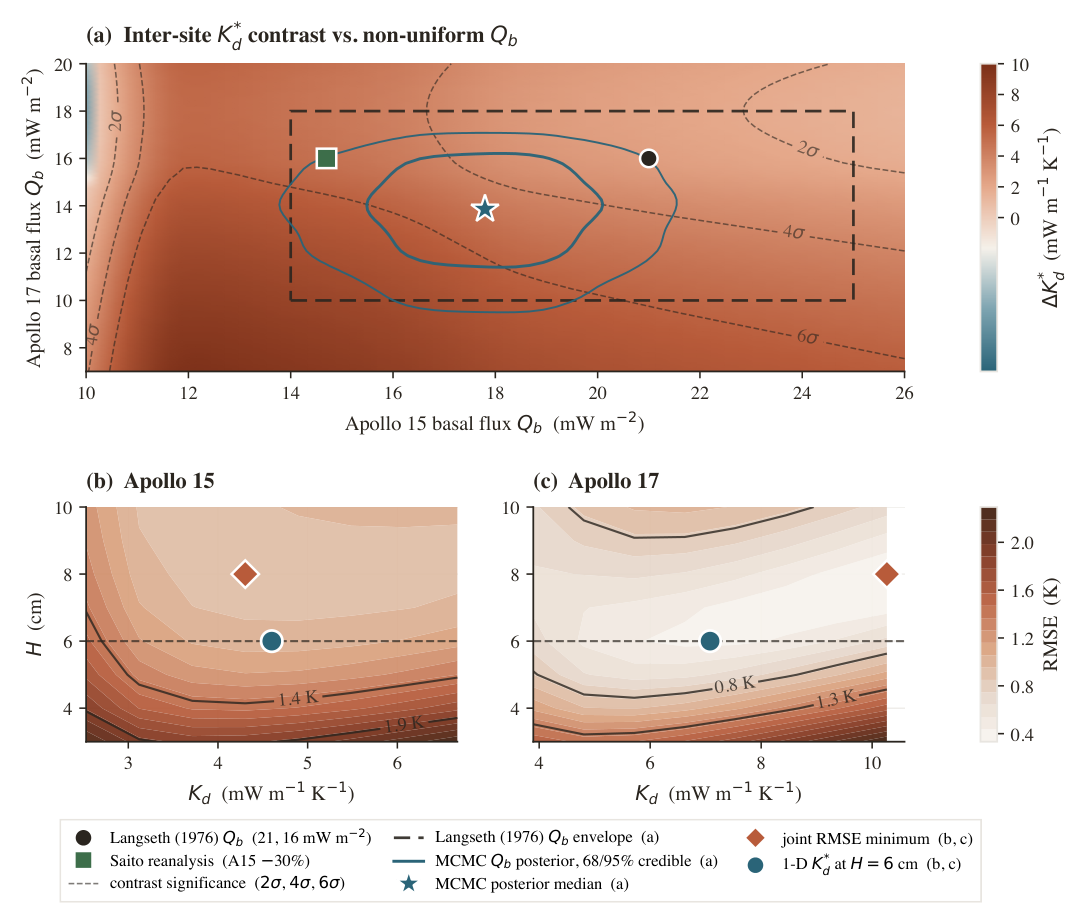

In [2]:
from make_results_figures import fig_robustness
fig_robustness(d, FIGS / 'fig_robustness.pdf')
show_fig('fig_robustness')

## Fig 11 — α-sweep (Martínez per-site density retrieval)

A cross-check using the *other* published conductivity form. The Martínez
K(T, ρ) model is given one per-site lever — the deep bulk density ρ_d,
expressed as α = ρ_d / 1800 — and we sweep α against the deep-sensor RMSE
at each site.

**What to look for:** each site prefers a different α (density), telling
the same story as the K_d contrast but through a different model — so the
conclusion isn't an artefact of choosing the Hayne form.

  -> fig_prior_estimates.pdf  (K_eff = 9.3/14.6 mW/m/K)


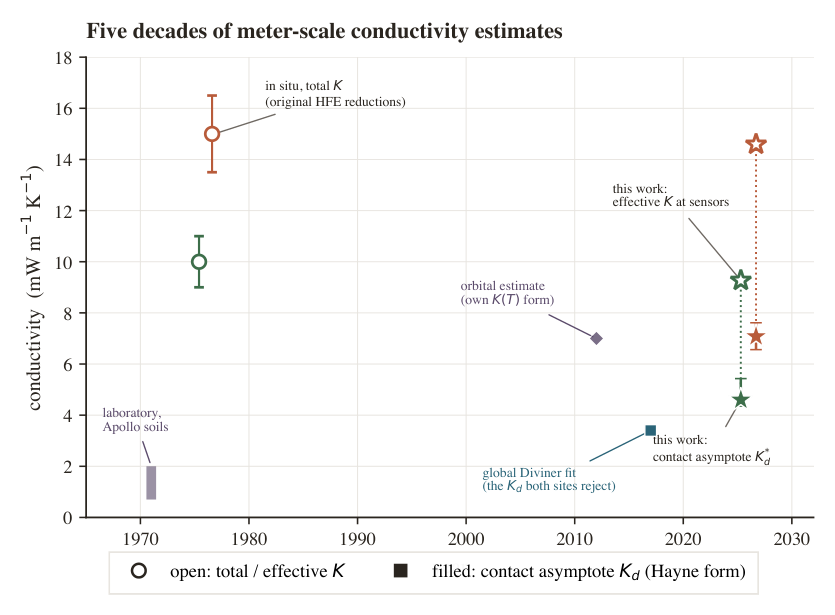

In [3]:
import make_prior_estimates_figure
make_prior_estimates_figure.main()   # -> figures/fig_prior_estimates.pdf (the letter's Fig 10)
show_fig('fig_prior_estimates')

## Table 4 — Pooled-fit model comparison (why "conductivity," not "flux")

An AICc comparison of three models fit to both sites at once:
**M1** = per-site K_d with Q_b fixed; **M2** = one shared K_d with Q_b
free per site; **M3** = one shared K_d with Q_b fixed. AICc rewards fit
quality while penalising extra free parameters.

**What to look for:** M1 wins by ΔAICc ≈ 5. That is the formal statement
that the inter-site difference is better explained as a **conductivity**
contrast than as a basal-**flux** contrast.

In [4]:
import pandas as pd
# Table 4 in the paper is the POOLED three-model comparison (M1/M2/M3),
# from results/uniform_kd_test.json.
t4 = json.loads((OUTPUT / 'uniform_kd_test.json').read_text())
order = [('M1', 'M1_variable_kd',        'per-site K_d, Q_b fixed'),
         ('M2', 'M2_uniform_kd_free_qb', 'shared K_d, Q_b free'),
         ('M3', 'M3_uniform_kd_fixed_qb','shared K_d, Q_b fixed')]
rows = []
for tag, key, desc in order:
    m = t4[key]
    rows.append({'Model': f'{tag}: {desc}',
                 'RMSE (K)': round(m['rmse'], 3),
                 'Delta AICc': round(m['delta_aicc'], 2)})
pd.DataFrame(rows)

,Model,RMSE (K),Delta AICc
0,"M1: per-site K_d, Q_b fixed",0.644,0.08
1,"M2: shared K_d, Q_b free",0.609,0.52
2,"M3: shared K_d, Q_b fixed",0.681,0.00


## Final sanity check — all paper figures present

In [5]:
expected = [
    'fig_intro_probe.pdf',
    'fig_context_map.pdf',
    'fig_apollo_timeline_probes.pdf',
    'fig_amplitude_vs_depth.pdf',
    'fig_apollo_mean_T_profile.pdf',
    'fig_kd_sweep.pdf',
    'fig_bootstrap.pdf',
    'fig_thermal_profiles.pdf',
    'fig_diviner_closure.pdf',
    'fig_robustness.pdf',
    'fig_prior_estimates.pdf',
]
missing = [f for f in expected if not (FIGS / f).exists()]
if missing:
    print('MISSING figures:')
    for f in missing:
        print('   ', f)
else:
    print('All 11 paper figures present in figures/')
    print()
    print('Now compile the manuscript:')
    print('    cd paper/letter && latexmk -pdf letter.tex')

All 11 paper figures present in figures/

Now compile the manuscript:
    cd paper/letter && latexmk -pdf letter.tex
